# Projet sur la consommation de carburants en France

### Programmation pour la science des données 2024-2025


##### Pauline Dumas & Emeline Lavaux

In [30]:
import gzip
import shutil
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



1.   Collecte des données





*   Attendu #1



In [31]:
# Nous commencons notre projet par importer les données Prix2023 depuis le lien Github
!wget -O Prix2023.csv.gz 'https://github.com/rvm-courses/GasPrices/raw/master/Prix2023.csv.gz'

--2025-01-05 22:48:20--  https://github.com/rvm-courses/GasPrices/raw/master/Prix2023.csv.gz
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rvm-courses/GasPrices/master/Prix2023.csv.gz [following]
--2025-01-05 22:48:21--  https://raw.githubusercontent.com/rvm-courses/GasPrices/master/Prix2023.csv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24645369 (24M) [application/octet-stream]
Saving to: ‘Prix2023.csv.gz’

Prix2023.csv.gz     100%[===================>]  23.50M  --.-KB/s    in 0.08s   

2025-01-05 22:48:21 (296 MB/s) - ‘Prix2023.csv.gz’ saved [24645369/24645369]



In [32]:
# Afin d'ouvrir les données nous décompressons le fichier afin d'accéder aux données au format csv
with gzip.open('Prix2023.csv.gz', 'rb') as f_in:
    with open('Prix2023.csv', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

# Enfin nous établissons le data frame que nous allons utiliser pour notre projet. Les noms des colonnes sont définis manuellement pour correspondre aux données attendues. Le séparateur utilisé dans le fichier csv est ";".
column_names = [
    'id_pdv', 'cp', 'pop', 'latitude', 'longitude',
    'date', 'id_carburant', 'nom_carburant', 'prix'
]
df = pd.read_csv('Prix2023.csv', delimiter=';', header=None, names=column_names)

# Nous vérifions la taille de notre data frame
df.shape

(4687530, 9)

In [33]:
# Enfin, nous affichons les 5 premières lignes de notre df afin de vérifier la structure des données
df.head()

,id_pdv,cp,pop,latitude,longitude,date,id_carburant,nom_carburant,prix
0,1000001,1000,R,4620100.0,519800.0,2023-01-02T07:53:26,1.0,Gazole,1.867
1,1000001,1000,R,4620100.0,519800.0,2023-01-05T09:33:37,1.0,Gazole,1.877
2,1000001,1000,R,4620100.0,519800.0,2023-01-09T14:51:49,1.0,Gazole,1.875
3,1000001,1000,R,4620100.0,519800.0,2023-01-11T09:23:54,1.0,Gazole,1.859
4,1000001,1000,R,4620100.0,519800.0,2023-01-13T09:07:40,1.0,Gazole,1.862


2.   Préparation des données




*   Attendu #2


In [34]:
# Nous convesrtissons les colonnes "date" et "prix" dans le bon format pour pouvoir les utiliser et interpéter dans notre projet
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%dT%H:%M:%S')
df['prix'] = df['prix'] / 1000

# On vérifie les valeurs manquantes
missing_values = df.isnull().sum()
print(missing_values)

# Nous extraylons de la colonne "date" : l'année, le mois et la semaine de l'année
df['année'] = df['date'].dt.year
df['mois'] = df['date'].dt.month
df['semaine'] = df['date'].dt.isocalendar().week

# Puis, on divise par la bonne puissance de 10 pour obtenir les vraies coordonnées pour la latitude et londitude afin de pouvoir établir une cartographie
df['latitude'] = df['latitude'] / 10**5
df['longitude'] = df['longitude'] / 10**5

id_pdv              0
cp                  0
pop                 0
latitude           69
longitude          68
date             4177
id_carburant     4177
nom_carburant    4177
prix             4177
dtype: int64


On remarque qu'il y peu de valeurs manquantes (environ 0.09%). Le dataset est alors relativement complet. Nous pouvons alors continuer notre projet sans faire d'imputation.



*   Attendu #3

Nous cherchons à évaluer les types de carburants disponibles dans notre base de données afin d'identifier les plus pertinents pour des analyses futures, et de décider lesquels pourraient être exclus en raison de leur faible représentativité ou pertinence.

Pour cela, nous avons calculé les stratistiques de base, telles que la moyenne, écart-type, et le compte des prix pour chaque type de carburant.

Ensuite nous établissons un seuil minimal d'observations de 500 afin d'assurer que les données utilisées pour les analyses futures soient assez représentatives.

In [35]:
# Nous calculons les statistiques de base pour chaque type de carburant
carburant_stats = df.groupby('nom_carburant')['prix'].agg(['mean', 'std', 'count'])
print("Statistiques des prix par type de carburant :\n", carburant_stats)

Statistiques des prix par type de carburant :
                    mean       std    count
nom_carburant                             
E10            0.001873  0.000096  1176889
E85            0.001079  0.000098   479380
GPLc           0.000996  0.000089   204305
Gazole         0.001821  0.000118  1398374
SP95           0.001887  0.000083   314626
SP98           0.001953  0.000101  1109779


Nous remarquons que E10 et Gazole sont les types de carburant le plus d'observations, avec respectivement environ 1,18 million et 1,4 million d'observations relevése. Le SP98 les suit avec environ 1,11 million.
E85, SP95 et GPLc ont moins de données. Cependant, bien que le SP95 soit moins fréquent que l'E85, il pourrait être intéressant dans notre projet, car il représente une alternative courante au SP98.

Finalement, nous pouvons alors dire que les carburants intéressants sont Gazole, E10, SP98 et SP95.
Nous décidons alors de filtrer les carburants E85 et GPLc.

In [36]:
# Nous filtrons les données pour enlever GPLc et E85
carburants_a_filtrer = ['GPLc', 'E85']
df_filtré = df[~df['nom_carburant'].isin(carburants_a_filtrer)]

# Nous calculons les statistiques après filtrage pour confirmer l'exclusion de GPLc et E85
carburant_stats_après = df_filtré.groupby('nom_carburant')['prix'].agg(['mean', 'std', 'count'])
print("Statistiques des prix par type de carburant après filtrage :\n", carburant_stats_après)

# Nous filtrons les carburants avec un nombre d'observations suffisant, toujours sur le df_filtré
carburants_à_garder = carburant_stats_après[carburant_stats_après['count'] > 1000].index
df_filtré = df_filtré[df_filtré['nom_carburant'].isin(carburants_à_garder)]

# Enfin, nous affichons les premières lignes du DataFrame filtré pour vérifier la structure des données
print("\nDataFrame après filtrage :")
print(df_filtré.head())

Statistiques des prix par type de carburant après filtrage :
                    mean       std    count
nom_carburant                             
E10            0.001873  0.000096  1176889
Gazole         0.001821  0.000118  1398374
SP95           0.001887  0.000083   314626
SP98           0.001953  0.000101  1109779

DataFrame après filtrage :
    id_pdv    cp pop  latitude  longitude                date  id_carburant  \
0  1000001  1000   R    46.201      5.198 2023-01-02 07:53:26           1.0   
1  1000001  1000   R    46.201      5.198 2023-01-05 09:33:37           1.0   
2  1000001  1000   R    46.201      5.198 2023-01-09 14:51:49           1.0   
3  1000001  1000   R    46.201      5.198 2023-01-11 09:23:54           1.0   
4  1000001  1000   R    46.201      5.198 2023-01-13 09:07:40           1.0   

  nom_carburant      prix   année  mois  semaine  
0        Gazole  0.001867  2023.0   1.0        1  
1        Gazole  0.001877  2023.0   1.0        1  
2        Gazole  0.00187

Finalement, nous avons un nouveau data frame "df_filtré" garantissant que nos analyses futures soient basées sur des données plus pertinentes et fiables, en excluant les 2 types de carburants moins utiles.
Nous allons donc pousuivre notre projet avec ce data frame filtré.




*   Attendu #4





In [37]:
# Calcul du prix moyen journalier par type de carburant à l'échelle de la France sur le DataFrame filtré
prix_moyen_journalier_filtré = df_filtré.groupby(['date', 'nom_carburant'])['prix'].mean().reset_index()
prix_moyen_journalier_filtré.rename(columns={'prix': 'prix_moyen_jour'}, inplace=True)

# Nous fusionnons le prix moyen journalier avec le DataFrame filtré
df_filtré = df_filtré.merge(prix_moyen_journalier_filtré, on=['date', 'nom_carburant'])

# Puis, nous calculons l'indice de prix selon la formule donnée sur le DataFrame filtré
df_filtré['indice_de_prix'] = 100 * ((df_filtré['prix'] - df_filtré['prix_moyen_jour']) / df_filtré['prix_moyen_jour'] + 1)

# Nous visualisons les premiers résultats pour vérifier la structure
print(df_filtré.head())

    id_pdv    cp pop  latitude  longitude                date  id_carburant  \
0  1000001  1000   R    46.201      5.198 2023-01-02 07:53:26           1.0   
1  1000001  1000   R    46.201      5.198 2023-01-05 09:33:37           1.0   
2  1000001  1000   R    46.201      5.198 2023-01-09 14:51:49           1.0   
3  1000001  1000   R    46.201      5.198 2023-01-11 09:23:54           1.0   
4  1000001  1000   R    46.201      5.198 2023-01-13 09:07:40           1.0   

  nom_carburant      prix   année  mois  semaine  prix_moyen_jour  \
0        Gazole  0.001867  2023.0   1.0        1         0.001867   
1        Gazole  0.001877  2023.0   1.0        1         0.001877   
2        Gazole  0.001875  2023.0   1.0        2         0.001875   
3        Gazole  0.001859  2023.0   1.0        2         0.001859   
4        Gazole  0.001862  2023.0   1.0        2         0.001909   

   indice_de_prix  
0      100.000000  
1      100.000000  
2      100.000000  
3      100.000000  
4       97



*   Attendu #5


In [38]:
# Calcul de l'Index de la semaine en utilisant .isocalendar().week afin d'extraire le numéro de la semaine conforme aux standards ISO (lundi comme premier jour de la semaine)
df_filtré['date'] = pd.to_datetime(df_filtré['date'])
df_filtré['Index de la semaine'] = df_filtré['date'].dt.isocalendar().week

# On vérifie que l'Index de la semaine a bien été appliqué
print(df_filtré.head())

    id_pdv    cp pop  latitude  longitude                date  id_carburant  \
0  1000001  1000   R    46.201      5.198 2023-01-02 07:53:26           1.0   
1  1000001  1000   R    46.201      5.198 2023-01-05 09:33:37           1.0   
2  1000001  1000   R    46.201      5.198 2023-01-09 14:51:49           1.0   
3  1000001  1000   R    46.201      5.198 2023-01-11 09:23:54           1.0   
4  1000001  1000   R    46.201      5.198 2023-01-13 09:07:40           1.0   

  nom_carburant      prix   année  mois  semaine  prix_moyen_jour  \
0        Gazole  0.001867  2023.0   1.0        1         0.001867   
1        Gazole  0.001877  2023.0   1.0        1         0.001877   
2        Gazole  0.001875  2023.0   1.0        2         0.001875   
3        Gazole  0.001859  2023.0   1.0        2         0.001859   
4        Gazole  0.001862  2023.0   1.0        2         0.001909   

   indice_de_prix  Index de la semaine  
0      100.000000                    1  
1      100.000000           



3.   Visualisation des données





*   Attendu #6



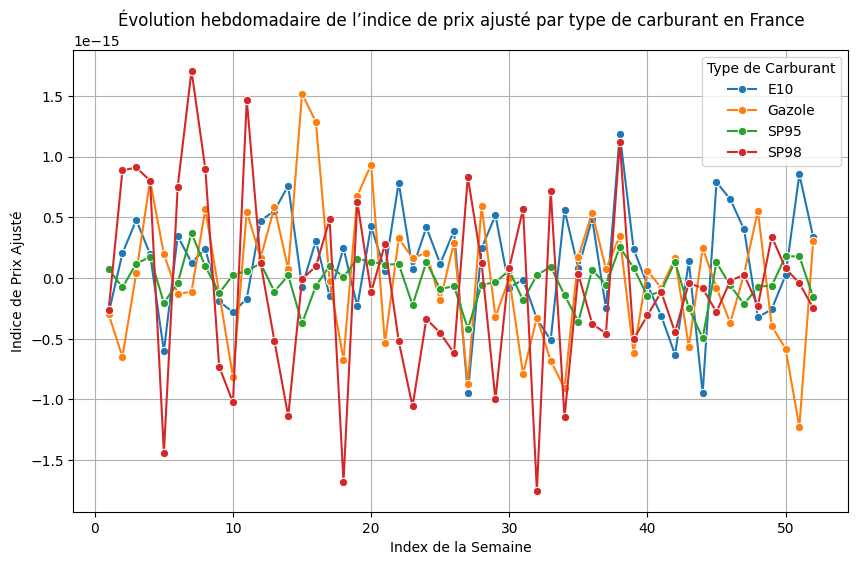

In [39]:
# Recalcul de l'indice de prix pour s'assurer qu'il reflète les variations par rapport à la moyenne nationale
df_filtré['indice_de_prix'] = 100 * ((df_filtré['prix'] - df_filtré['prix_moyen_jour']) / df_filtré['prix_moyen_jour'])

# Calcul de l'indice de prix moyen hebdomadaire pour chaque type de carburant
prix_moyen_hebdo = df_filtré.groupby(['Index de la semaine', 'nom_carburant'])['indice_de_prix'].mean().reset_index()

# Préparation du graphique avec la formule ajustée
plt.figure(figsize=(10, 6))
sns.lineplot(data=prix_moyen_hebdo, x='Index de la semaine', y='indice_de_prix', hue='nom_carburant', marker='o')

# Ajout de titres et labels
plt.title('Évolution hebdomadaire de l’indice de prix ajusté par type de carburant en France')
plt.xlabel('Index de la Semaine')
plt.ylabel('Indice de Prix Ajusté')
plt.legend(title='Type de Carburant')

# Afficher le graphique avec une grille
plt.grid(True)
plt.show()

Nous observons une grande volatilité pour tous les types de carburants, avec des fluctuations significatives d'une semaine à l'autre. Cette volatillité peut être expliqué par les flucuations du coût des matières premières liées au conflit en Ukraine.
Nous remarquons que SP98 et E10 montrent les plus grands écarts d'indices de prix ajustés, suggérant une sensibilité plus élevée aux facteurs de marché ou une moins grande uniformité dans la distribution de leurs prix à travers le pays.
De plus, il semble y avoir des tendances saisonnières. On remarque des hausses ou des baisses coordonnées entre tous les carburants autour des mêmes semaines. Cela reflète des périodes de forte demande, comme lors des vacances scolaires par exemple.



*   Bonus : visualisation des données


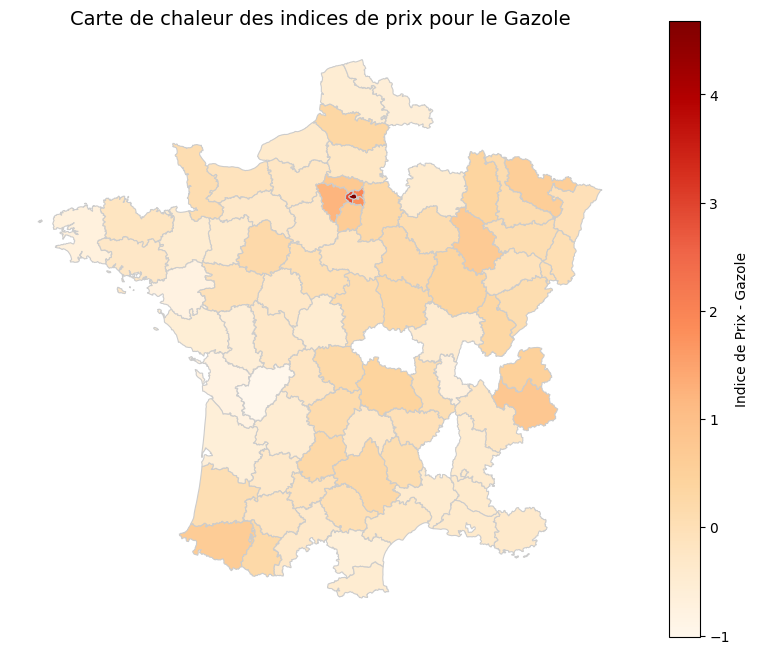

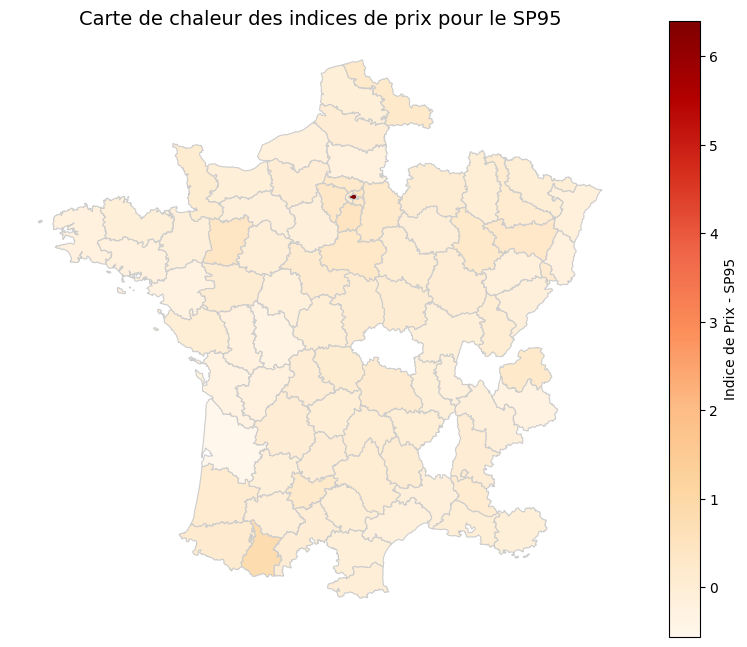

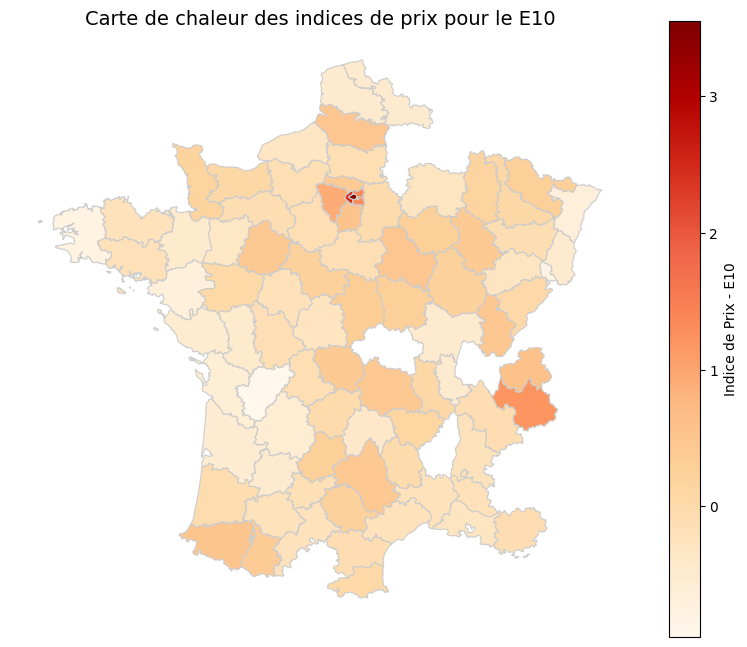

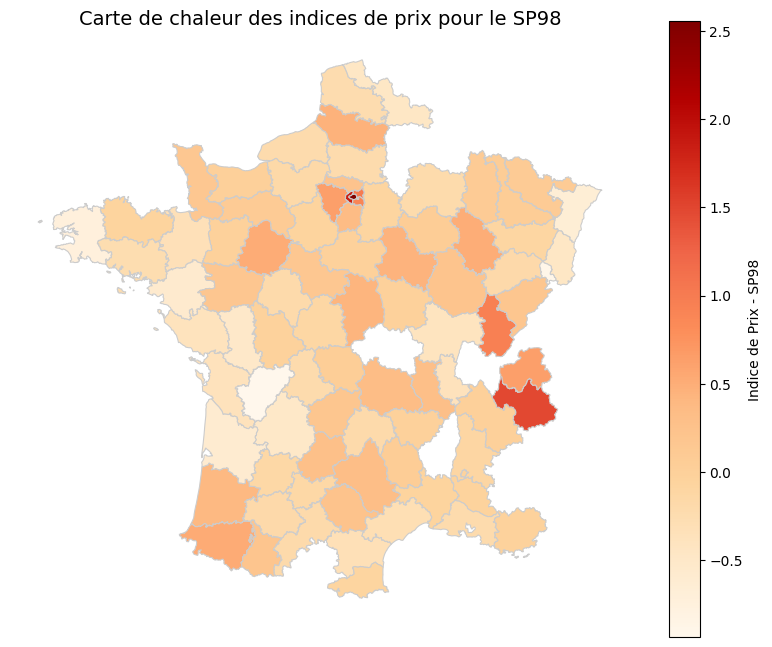

In [40]:
# Afin de représenter une carte pour chaque type de carburant de notre data frame filtré nous commencons par charger les données géographiques des départements de France depuis GeoJSON
url_departements = "https://france-geojson.gregoiredavid.fr/repo/departements.geojson"
gdf_departements = gpd.read_file(url_departements)

# Ensuite, nous passons à l'extraction du code postal pour associer aux départements
df_filtré['departement'] = df_filtré['cp'].astype(str).str[:2]
indice_prix_par_departement = df_filtré.groupby(['departement', 'nom_carburant'])['indice_de_prix'].mean().reset_index()

# Nous associons les données des indices de prix calculé au GeoDataFrame des départements
gdf_departements['code'] = gdf_departements['code']
gdf_departements = gdf_departements.merge(
    indice_prix_par_departement,
    how='left',
    left_on='code',
    right_on='departement'
)

# Nous générons une carte de chaleur pour chaque type de carburant en créant une boucle qui itère sur les types de carburant disponibles dans les données filtrées
types_carburant = df_filtré['nom_carburant'].unique()

for carburant in types_carburant:
    gdf_carburant = gdf_departements[gdf_departements['nom_carburant'] == carburant]

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    gdf_carburant.plot(
        column='indice_de_prix',
        cmap='OrRd',
        linewidth=0.8,
        ax=ax,
        edgecolor='0.8',
        legend=True,
        legend_kwds={
            'label': f"Indice de Prix - {carburant}",
            'orientation': "vertical"
        }
    )

    # Nous faisons la mise en page de la carte
    ax.set_title(f"Carte de chaleur des indices de prix pour le {carburant}", fontsize=14)
    ax.set_axis_off()

    plt.show()



4.   Modélisation





*   Attendu #7


In [41]:
# Agrégation du prix moyen par type de carburant par jour au niveau national
prix_journalier = df_filtré.groupby(['date', 'nom_carburant'])['prix'].mean().reset_index()
print(prix_journalier.head())

# Nous utilisons le décalage des prix pour prédire le prix du jour suivant
def prepare_data(data, lags):
    for lag in range(1, lags + 1):
        data[f'prix_lag_{lag}'] = data.groupby('nom_carburant')['prix'].shift(lag)
    data.dropna(inplace=True)
    return data

# On fait un décalage d'un jour
prix_journalier = prepare_data(prix_journalier, 1)

                 date nom_carburant      prix
0 2023-01-01 00:00:00           E10  0.001787
1 2023-01-01 00:00:00        Gazole  0.001954
2 2023-01-01 00:00:00          SP95  0.001842
3 2023-01-01 00:00:00          SP98  0.001883
4 2023-01-01 00:00:25        Gazole  0.001947


Nous allons appliquer un modèle de régression linéaire pour prédire les prix.

In [42]:
def train_model(data, carburant):
    car_data = data[data['nom_carburant'] == carburant]
    X = car_data[['prix_lag_1']]
    y = car_data['prix']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    print(f'MSE pour {carburant}: {mse}')
    return X_test, y_test, y_pred, model

# Entraîner un modèle pour 'Gazole' et obtenir les prédictions
X_test, y_test, y_pred, model_gazole = train_model(prix_journalier, 'Gazole')

MSE pour Gazole: 7.398408895089277e-09


Nous avons évalué le modèle en utilisant l'erreur quadratique moyenne et remarquons quelle est relativement faible. Le modèle semble alors assez bien prédire les prix basés sur les données antérieures.

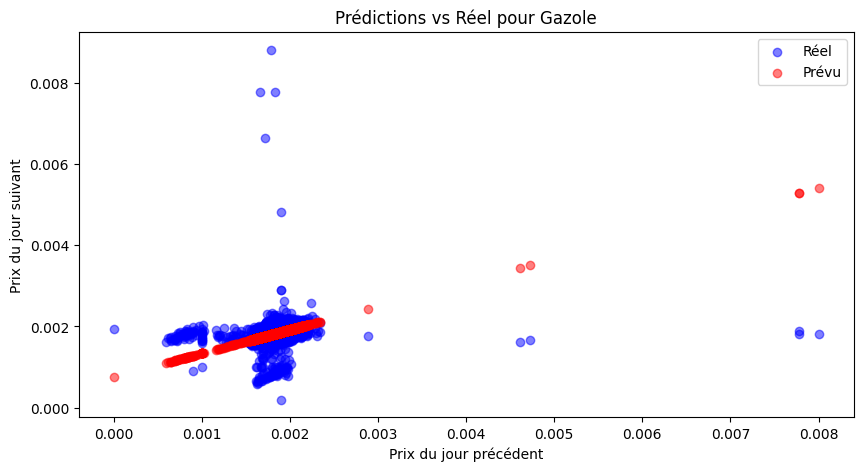

In [43]:
# Enfin, nous visualisons les prédictions versus les valeurs réelles afin d'évaluer visuellement l'efficacité du modèle
def plot_predictions(X_test, y_test, y_pred, carburant):
    plt.figure(figsize=(10, 5))
    plt.scatter(X_test['prix_lag_1'], y_test, color='blue', label='Réel', alpha=0.5)
    plt.scatter(X_test['prix_lag_1'], y_pred, color='red', label='Prévu', alpha=0.5)
    plt.title(f'Prédictions vs Réel pour {carburant}')
    plt.xlabel('Prix du jour précédent')
    plt.ylabel('Prix du jour suivant')
    plt.legend()
    plt.show()

# Visualiser les prédictions pour 'Gazole'
plot_predictions(X_test, y_test, y_pred, 'Gazole')

Le modèle semble bien perfomrer pour des prédictions à court terme basées sur des tendances récentes. Cependant, pour des prdictions à lus long terme, des modèles plus complexes pourraient être nécessaires. Il serait alors intéressant d'incorporer des variables exogènes, comme des changeement de politique de prix, événements géo-politiques et économiques, afin d'améliorer la précision des prédictions à court et long terme.